# 🚗 KSI Toronto — Killed or Seriously Injured Collision Analysis
## Step 1 — Data Loading & Exploratory Data Analysis (EDA)
**Dataset:** Toronto Police Service KSI Collisions (2006–2023)  
**Objective:** Predict whether a collision will result in a fatality or not.

## 1.1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8')

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


## 1.2 — Load Dataset
📸 **CAPTURE 1 : Screenshot of this cell output (shape + head)**

In [2]:
DATA_PATH    = r'C:\Users\HP\Desktop\Artificial Intelligence - Software Engineering Technology (Fast-Track)\26W --Supervised Learning (SEC. 402)\COMP247_KSI_Project\data\TOTAL_KSI_3737821728629277523.csv'
OUTPUTS_PATH = r'C:\Users\HP\Desktop\Artificial Intelligence - Software Engineering Technology (Fast-Track)\26W --Supervised Learning (SEC. 402)\COMP247_KSI_Project\outputs\\'
POWERBI_PATH = r'C:\Users\HP\Desktop\Artificial Intelligence - Software Engineering Technology (Fast-Track)\26W --Supervised Learning (SEC. 402)\COMP247_KSI_Project\powerbi\\'

import os
os.makedirs(OUTPUTS_PATH, exist_ok=True)
os.makedirs(POWERBI_PATH, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print('✅ Dataset loaded successfully')
print(f'📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

✅ Dataset loaded successfully
📊 Shape: 18,957 rows × 54 columns


,OBJECTID,INDEX,ACCNUM,DATE,TIME,STREET1,STREET2,OFFSET,ROAD_CLASS,DISTRICT,LATITUDE,LONGITUDE,ACCLOC,TRAFFCTL,VISIBILITY,LIGHT,RDSFCOND,ACCLASS,IMPACTYPE,INVTYPE,INVAGE,INJURY,FATAL_NO,INITDIR,VEHTYPE,MANOEUVER,DRIVACT,DRIVCOND,PEDTYPE,PEDACT,PEDCOND,CYCLISTYPE,CYCACT,CYCCOND,PEDESTRIAN,CYCLIST,AUTOMOBILE,MOTORCYCLE,TRUCK,TRSN_CITY_VEH,EMERG_VEH,PASSENGER,SPEEDING,AG_DRIV,REDLIGHT,ALCOHOL,DISABILITY,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,DIVISION,x,y
0,1,3389067,893184.0,1/1/2006 10:00:00 AM,236,WOODBINE AVE,O CONNOR DR,NaN,Major Arterial,Toronto and East York,43.699595,-79.318797,Intersection Related,No Control,Clear,Dark,Wet,Non-Fatal Injury,Approaching,Passenger,50 to 54,Major,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,NaN,NaN,NaN,NaN,Yes,Yes,Yes,NaN,Yes,NaN,60,Woodbine-Lumsden,60,Woodbine-Lumsden (60),D55,635468.3685,4.839881e+06
1,2,3389068,893184.0,1/1/2006 10:00:00 AM,236,WOODBINE AVE,O CONNOR DR,NaN,Major Arterial,Toronto and East York,43.699595,-79.318797,Intersection Related,No Control,Clear,Dark,Wet,Non-Fatal Injury,Approaching,Passenger,15 to 19,Minor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,NaN,NaN,NaN,NaN,Yes,Yes,Yes,NaN,Yes,NaN,60,Woodbine-Lumsden,60,Woodbine-Lumsden (60),D55,635468.3685,4.839881e+06
2,3,3389069,893184.0,1/1/2006 10:00:00 AM,236,WOODBINE AVE,O CONNOR DR,NaN,Major Arterial,Toronto and East York,43.699595,-79.318797,Intersection Related,No Control,Clear,Dark,Wet,Non-Fatal Injury,Approaching,Driver,55 to 59,Minor,NaN,North,"Automobile, Station Wagon",Going Ahead,Driving Properly,Normal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,NaN,NaN,NaN,NaN,Yes,Yes,Yes,NaN,Yes,NaN,60,Woodbine-Lumsden,60,Woodbine-Lumsden (60),D55,635468.3685,4.839881e+06
3,4,3389070,893184.0,1/1/2006 10:00:00 AM,236,WOODBINE AVE,O CONNOR DR,NaN,Major Arterial,Toronto and East York,43.699595,-79.318797,Intersection Related,No Control,Clear,Dark,Wet,Non-Fatal Injury,Approaching,Passenger,20 to 24,Minor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,NaN,NaN,NaN,NaN,Yes,Yes,Yes,NaN,Yes,NaN,60,Woodbine-Lumsden,60,Woodbine-Lumsden (60),D55,635468.3685,4.839881e+06
4,5,3389071,893184.0,1/1/2006 10:00:00 AM,236,WOODBINE AVE,O CONNOR DR,NaN,Major Arterial,Toronto and East York,43.699595,-79.318797,Intersection Related,No Control,Clear,Dark,Wet,Non-Fatal Injury,Approaching,Passenger,15 to 19,Minor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,NaN,NaN,NaN,NaN,Yes,Yes,Yes,NaN,Yes,NaN,60,Woodbine-Lumsden,60,Woodbine-Lumsden (60),D55,635468.3685,4.839881e+06


## 1.3 — Dataset Information
📸 **CAPTURE 2 : Screenshot of df.info() output**

In [3]:
print('📋 Dataset Information:')
print('='*60)
df.info()

📋 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18957 entries, 0 to 18956
Data columns (total 54 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   OBJECTID           18957 non-null  int64  
 1   INDEX              18957 non-null  int64  
 2   ACCNUM             14027 non-null  float64
 3   DATE               18957 non-null  object 
 4   TIME               18957 non-null  int64  
 5   STREET1            18957 non-null  object 
 6   STREET2            17251 non-null  object 
 7   OFFSET             3820 non-null   object 
 8   ROAD_CLASS         18471 non-null  object 
 9   DISTRICT           18728 non-null  object 
 10  LATITUDE           18957 non-null  float64
 11  LONGITUDE          18957 non-null  float64
 12  ACCLOC             13501 non-null  object 
 13  TRAFFCTL           18882 non-null  object 
 14  VISIBILITY         18933 non-null  object 
 15  LIGHT              18953 non-null  object 
 16 

## 1.4 — Statistical Summary
📸 **CAPTURE 3 : Screenshot of df.describe() output**

In [4]:
print('📊 Statistical Summary — Numerical Columns:')
df.describe()

📊 Statistical Summary — Numerical Columns:


,OBJECTID,INDEX,ACCNUM,TIME,LATITUDE,LONGITUDE,FATAL_NO,x,y
count,18957.000000,1.895700e+04,1.402700e+04,18957.000000,18957.000000,18957.000000,870.000000,18957.000000,1.895700e+04
mean,9479.000000,3.994181e+07,5.576714e+08,1364.956428,43.710299,-79.396490,28.752874,629181.568576,4.840951e+06
std,5472.558862,3.749731e+07,1.180026e+09,631.310388,0.056294,0.104484,17.657001,8364.337712,6.324585e+03
min,1.000000,3.363207e+06,2.530100e+04,0.000000,43.589678,-79.638390,1.000000,609625.702600,4.827328e+06
25%,4740.000000,5.408154e+06,1.034561e+06,924.000000,43.661727,-79.471469,14.000000,623177.000800,4.835532e+06
50%,9479.000000,7.820656e+06,1.220029e+06,1450.000000,43.702346,-79.397388,27.500000,629199.077800,4.840070e+06
75%,14218.000000,8.092292e+07,1.386958e+06,1852.000000,43.755945,-79.318286,42.000000,635424.041900,4.846036e+06
max,18957.000000,8.180752e+07,4.008024e+09,2359.000000,43.855445,-79.122974,78.000000,651024.087800,4.857444e+06


In [5]:
print('📊 Statistical Summary — Categorical Columns:')
df.describe(include='object')

📊 Statistical Summary — Categorical Columns:


,DATE,STREET1,STREET2,OFFSET,ROAD_CLASS,DISTRICT,ACCLOC,TRAFFCTL,VISIBILITY,LIGHT,RDSFCOND,ACCLASS,IMPACTYPE,INVTYPE,INVAGE,INJURY,INITDIR,VEHTYPE,MANOEUVER,DRIVACT,DRIVCOND,PEDTYPE,PEDACT,PEDCOND,CYCLISTYPE,CYCACT,CYCCOND,PEDESTRIAN,CYCLIST,AUTOMOBILE,MOTORCYCLE,TRUCK,TRSN_CITY_VEH,EMERG_VEH,PASSENGER,SPEEDING,AG_DRIV,REDLIGHT,ALCOHOL,DISABILITY,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,DIVISION
count,18957,18957,17251,3820,18471,18728,13501,18882,18933,18953,18928,18956,18930,18941,18957,10060,13680,15470,11004,9668,9666,3229,3227,3246,805,802,800,7688,1986,17230,1684,1169,1148,49,7183,2694,9836,1577,808,493,18957,18957,18957,18957,18957
unique,4128,1942,2822,494,11,4,10,10,8,9,9,3,10,19,21,4,5,32,16,13,10,16,15,10,22,11,10,1,1,1,1,1,1,1,1,1,1,1,1,1,159,159,141,141,17
top,8/17/2014 8:00:00 AM,YONGE ST,BATHURST ST,10 m West of,Major Arterial,Toronto and East York,At Intersection,No Control,Clear,Daylight,Dry,Non-Fatal Injury,Pedestrian Collisions,Driver,unknown,Major,East,"Automobile, Station Wagon",Going Ahead,Driving Properly,Normal,Pedestrian hit at mid-block,Crossing with right of way,Normal,Motorist turned left across cyclists path.,Driving Properly,Normal,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,1,West Humber-Clairville,77,Waterfront Communities-The Island (77),D42
freq,35,403,156,61,13376,6328,8774,9021,16373,10779,15231,16268,7684,8651,2625,6445,3388,7805,6542,4425,6158,810,1019,1842,140,444,557,7688,1986,17230,1684,1169,1148,49,7183,2694,9836,1577,808,493,597,597,740,740,1813


## 1.5 — Column Descriptions

In [6]:
# Column descriptions
col_descriptions = {
    'OBJECTID': 'Unique identifier',
    'ACCNUM': 'Accident number',
    'DATE': 'Date of collision',
    'TIME': 'Time of collision',
    'STREET1': 'Primary street',
    'STREET2': 'Secondary street',
    'ROAD_CLASS': 'Road classification',
    'DISTRICT': 'Toronto district',
    'LATITUDE': 'GPS Latitude',
    'LONGITUDE': 'GPS Longitude',
    'ACCLOC': 'Accident location type',
    'TRAFFCTL': 'Traffic control type',
    'VISIBILITY': 'Visibility conditions',
    'LIGHT': 'Light conditions',
    'RDSFCOND': 'Road surface condition',
    'ACCLASS': '🎯 TARGET — Fatal or Non-Fatal',
    'IMPACTYPE': 'Type of impact',
    'INVTYPE': 'Type of person involved',
    'INVAGE': 'Age of person involved',
    'INJURY': 'Injury severity',
    'INITDIR': 'Initial direction of vehicle',
    'VEHTYPE': 'Vehicle type',
    'MANOEUVER': 'Vehicle maneuver',
    'DRIVACT': 'Driver action',
    'DRIVCOND': 'Driver condition',
    'PEDTYPE': 'Pedestrian type',
    'PEDACT': 'Pedestrian action',
    'PEDCOND': 'Pedestrian condition',
    'CYCLISTYPE': 'Cyclist type',
    'CYCACT': 'Cyclist action',
    'CYCCOND': 'Cyclist condition',
    'PEDESTRIAN': 'Pedestrian involved (Yes/No)',
    'CYCLIST': 'Cyclist involved (Yes/No)',
    'AUTOMOBILE': 'Automobile involved (Yes/No)',
    'MOTORCYCLE': 'Motorcycle involved (Yes/No)',
    'TRUCK': 'Truck involved (Yes/No)',
    'SPEEDING': 'Speeding involved (Yes/No)',
    'AG_DRIV': 'Aggressive driving (Yes/No)',
    'REDLIGHT': 'Red light violation (Yes/No)',
    'ALCOHOL': 'Alcohol involved (Yes/No)',
    'DISABILITY': 'Disability involved (Yes/No)',
    'NEIGHBOURHOOD_158': 'Toronto neighbourhood',
    'DIVISION': 'Police division'
}

desc_df = pd.DataFrame(list(col_descriptions.items()), 
                        columns=['Column', 'Description'])
print('📋 Column Descriptions:')
desc_df

📋 Column Descriptions:


,Column,Description
0,OBJECTID,Unique identifier
1,ACCNUM,Accident number
2,DATE,Date of collision
3,TIME,Time of collision
4,STREET1,Primary street
5,STREET2,Secondary street
6,ROAD_CLASS,Road classification
7,DISTRICT,Toronto district
8,LATITUDE,GPS Latitude
9,LONGITUDE,GPS Longitude


## 1.6 — Target Variable Analysis
📸 **CAPTURE 4 : Screenshot of this cell output + chart**

🎯 Target Variable — ACCLASS Distribution:
ACCLASS
Non-Fatal Injury     16268
Fatal                 2670
Property Damage O       18
Name: count, dtype: int64

Percentage:
ACCLASS
Non-Fatal Injury     85.82%
Fatal                14.09%
Property Damage O     0.09%
Name: proportion, dtype: object


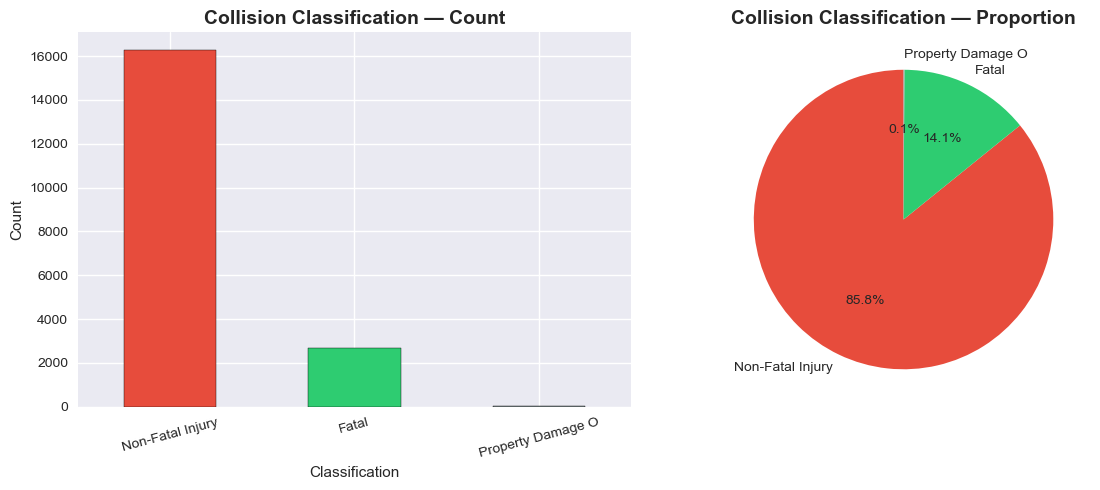

✅ Chart saved as target_distribution.png


In [7]:
print('🎯 Target Variable — ACCLASS Distribution:')
print('='*40)
print(df['ACCLASS'].value_counts())
print(f'\nPercentage:')
print(df['ACCLASS'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#e74c3c', '#2ecc71', '#95a5a6']
df['ACCLASS'].value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Collision Classification — Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Classification')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

# Pie chart
df['ACCLASS'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                   colors=colors, startangle=90)
axes[1].set_title('Collision Classification — Proportion', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as target_distribution.png')

## 1.7 — Missing Values Analysis
📸 **CAPTURE 5 : Screenshot of missing values output + heatmap**

In [16]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

missing_with_data = missing_df[missing_df['Missing Count'] > 0]
print(f'📊 Columns with missing values: {len(missing_with_data)}')
print('='*40)
missing_with_data

📊 Columns with missing values: 39


,Missing Count,Missing %
EMERG_VEH,18908,99.74
DISABILITY,18464,97.40
CYCCOND,18157,95.78
CYCACT,18155,95.77
CYCLISTYPE,18152,95.75
ALCOHOL,18149,95.74
FATAL_NO,18087,95.41
TRSN_CITY_VEH,17809,93.94
TRUCK,17788,93.83
REDLIGHT,17380,91.68


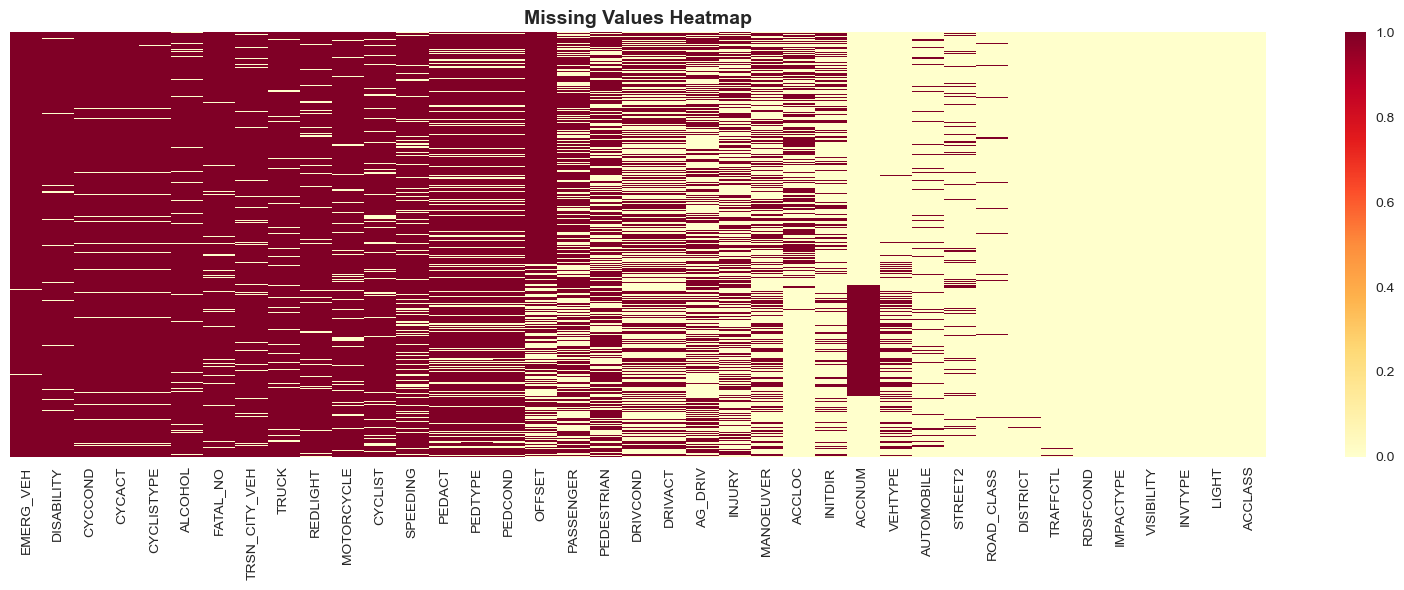

✅ Chart saved as missing_values_heatmap.png


In [9]:
# Missing values heatmap
plt.figure(figsize=(16, 6))
missing_cols = missing_df[missing_df['Missing Count'] > 0].index.tolist()
sns.heatmap(df[missing_cols].isnull(), 
            cbar=True, yticklabels=False, 
            cmap='YlOrRd')
plt.title('Missing Values Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('missing_values_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as missing_values_heatmap.png')

## 1.8 — Collisions Over Time
📸 **CAPTURE 6 : Screenshot of this chart**

<Figure size 1400x600 with 0 Axes>

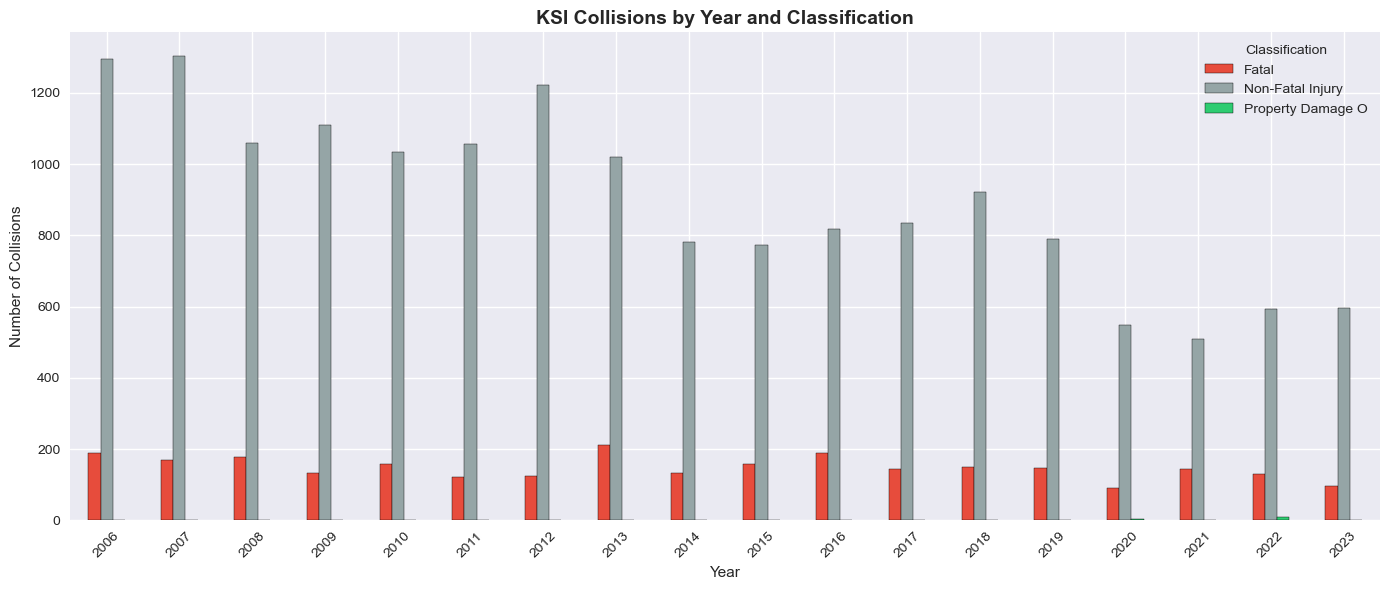

✅ Chart saved as collisions_by_year.png


In [10]:
# Parse date
df['DATE'] = pd.to_datetime(df['DATE'])
df['YEAR'] = df['DATE'].dt.year
df['MONTH'] = df['DATE'].dt.month
df['DAY_OF_WEEK'] = df['DATE'].dt.day_name()

# Collisions per year
yearly = df.groupby(['YEAR', 'ACCLASS']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 6))
yearly.plot(kind='bar', figsize=(14, 6), color=['#e74c3c', '#95a5a6', '#2ecc71'], 
            edgecolor='black')
plt.title('KSI Collisions by Year and Classification', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Collisions')
plt.legend(title='Classification')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('collisions_by_year.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as collisions_by_year.png')

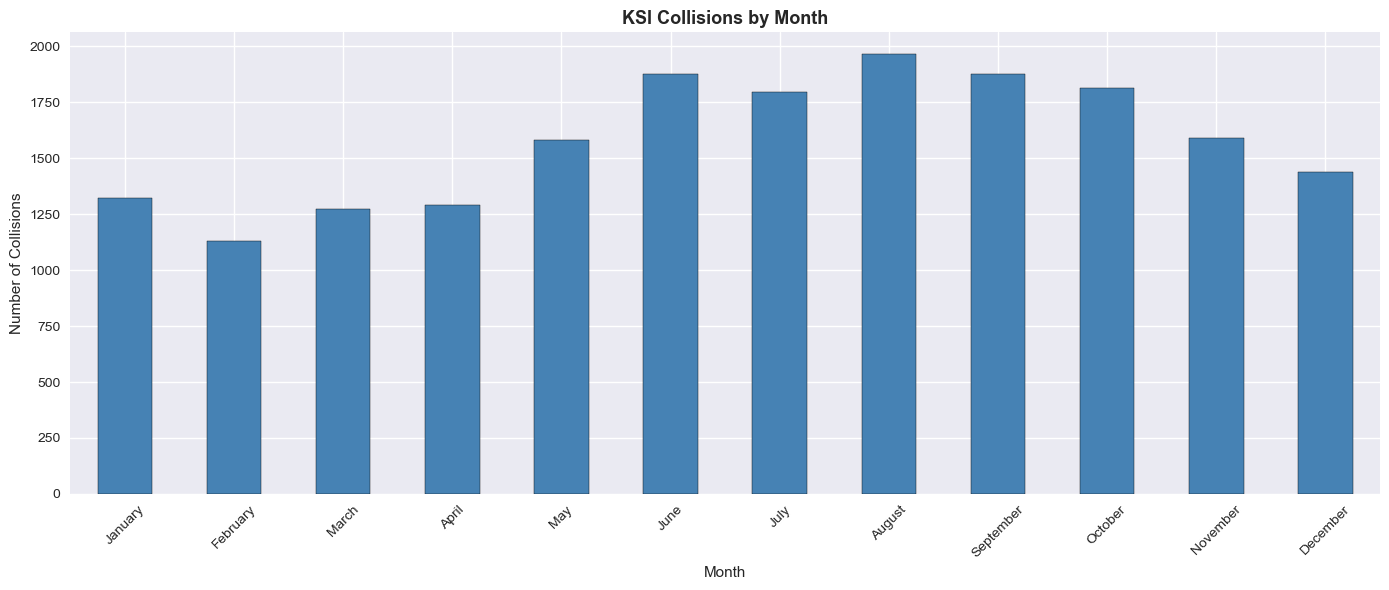

✅ Chart saved as collisions_by_month.png


In [17]:
# Collisions by Month
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
df['MONTH_NAME'] = pd.to_datetime(df['DATE']).dt.month_name()
monthly = df.groupby('MONTH_NAME').size().reindex(month_order)

plt.figure(figsize=(14, 6))
monthly.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('KSI Collisions by Month', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('collisions_by_month.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as collisions_by_month.png')

## 1.9 — Key Categorical Variables Analysis
📸 **CAPTURE 7 : Screenshot of these charts**

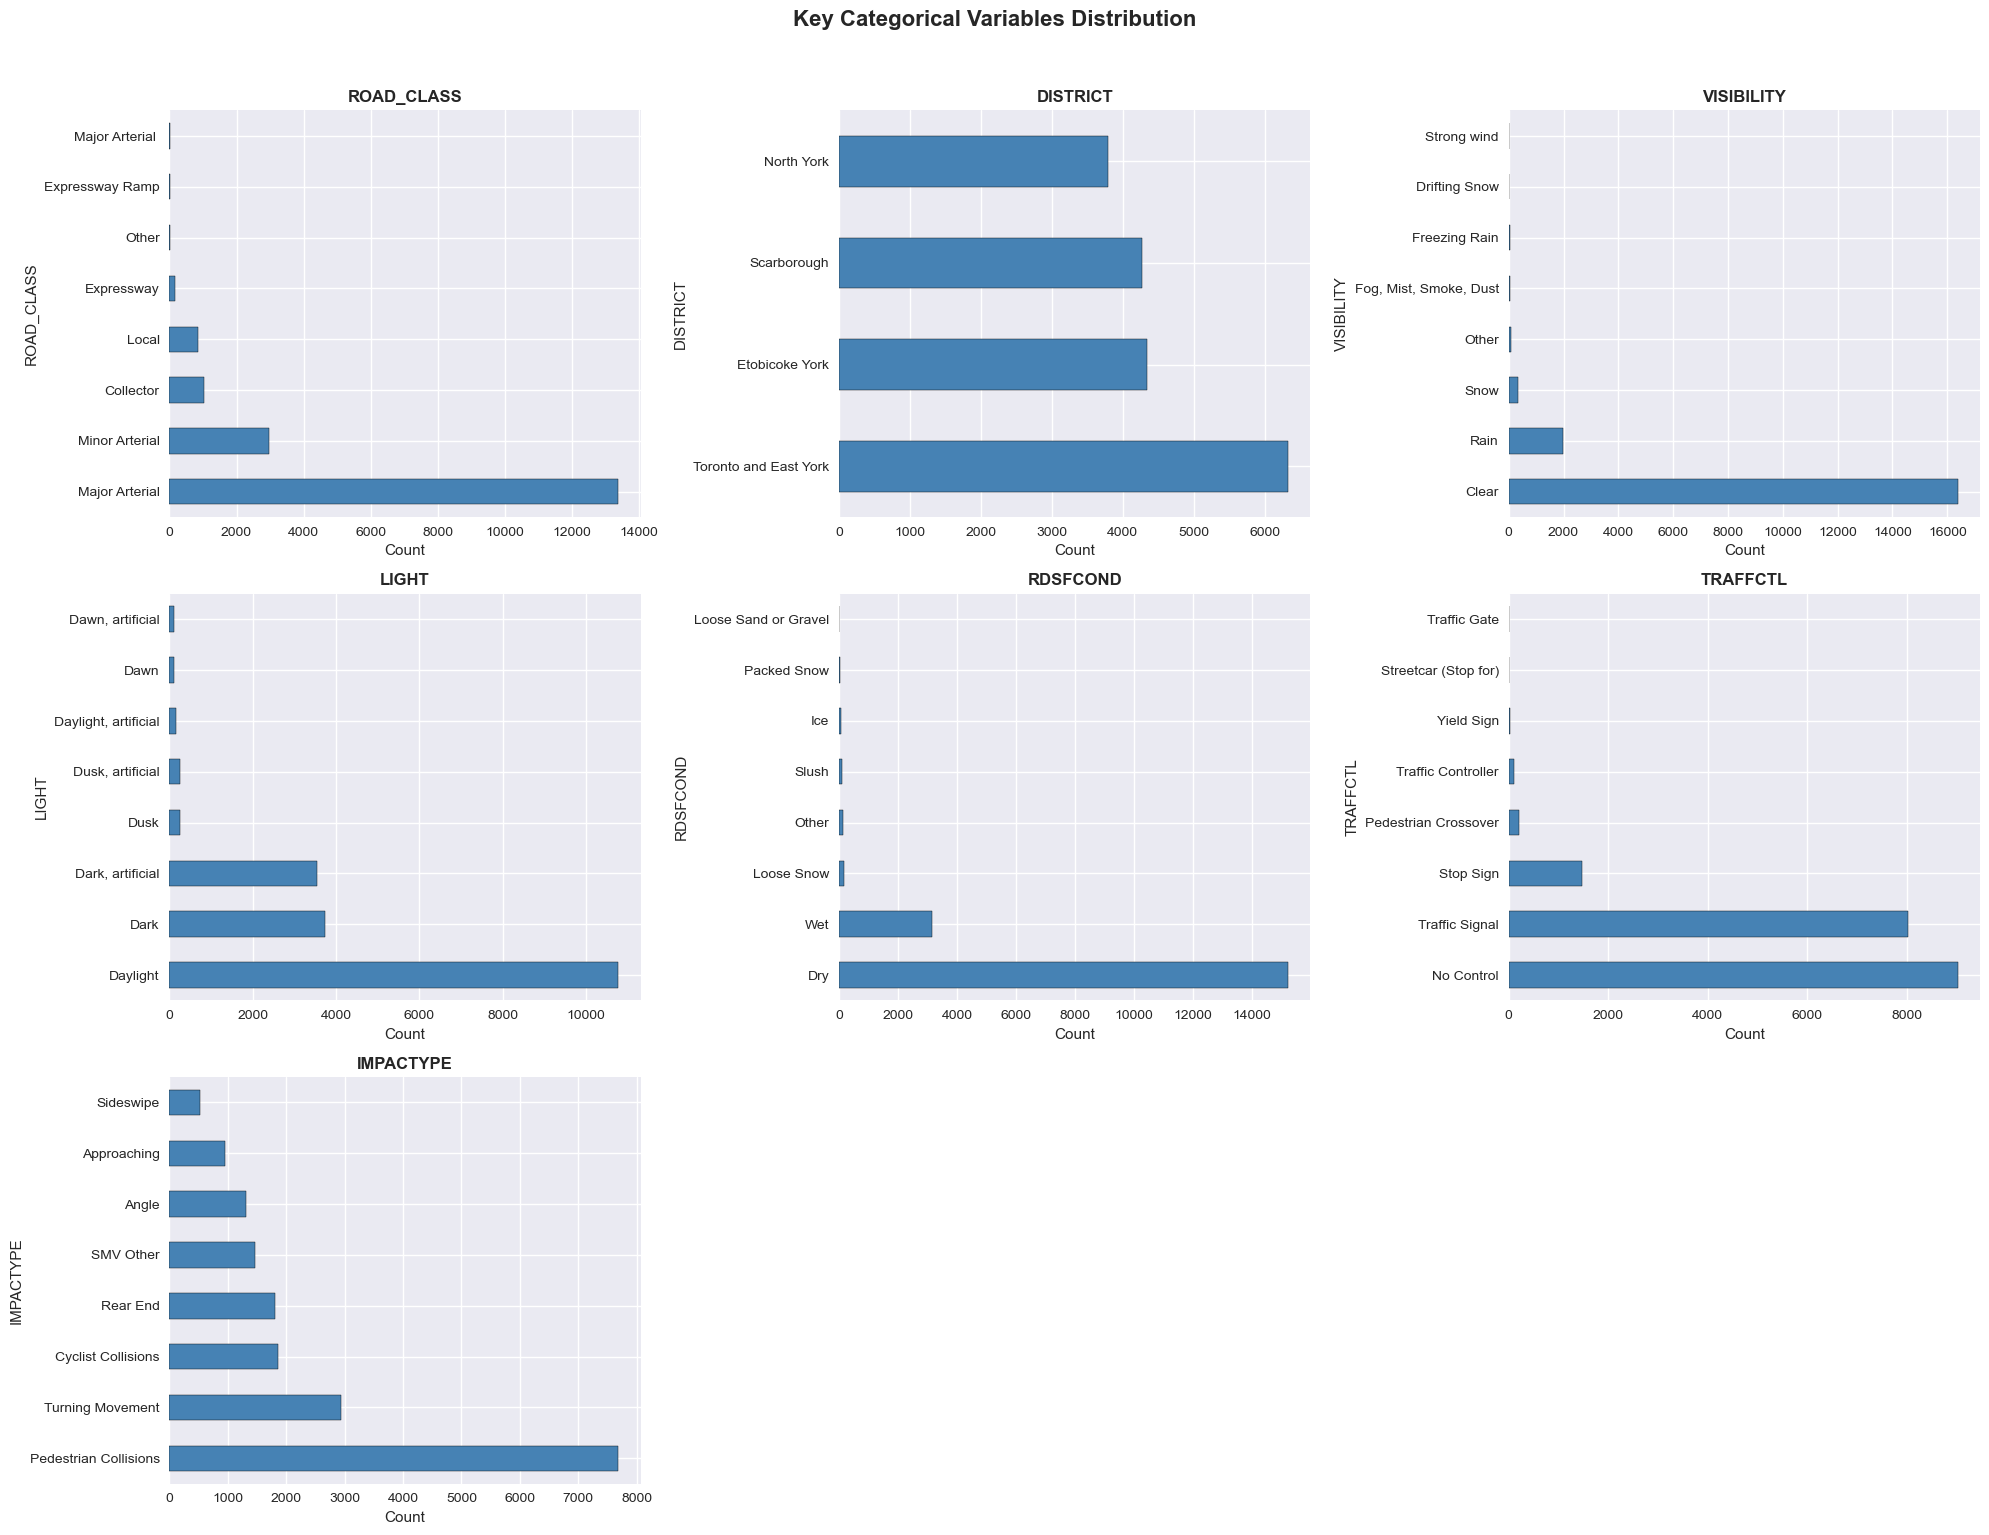

✅ Chart saved as categorical_distributions.png


In [11]:
# Key categorical columns to explore
cat_cols = ['ROAD_CLASS', 'DISTRICT', 'VISIBILITY', 'LIGHT', 
            'RDSFCOND', 'TRAFFCTL', 'IMPACTYPE']

fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    top_vals = df[col].value_counts().head(8)
    top_vals.plot(kind='barh', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Count')

# Hide unused subplots
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Key Categorical Variables Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as categorical_distributions.png')

## 1.10 — Fatal vs Non-Fatal by Key Factors
📸 **CAPTURE 8 : Screenshot of these charts**

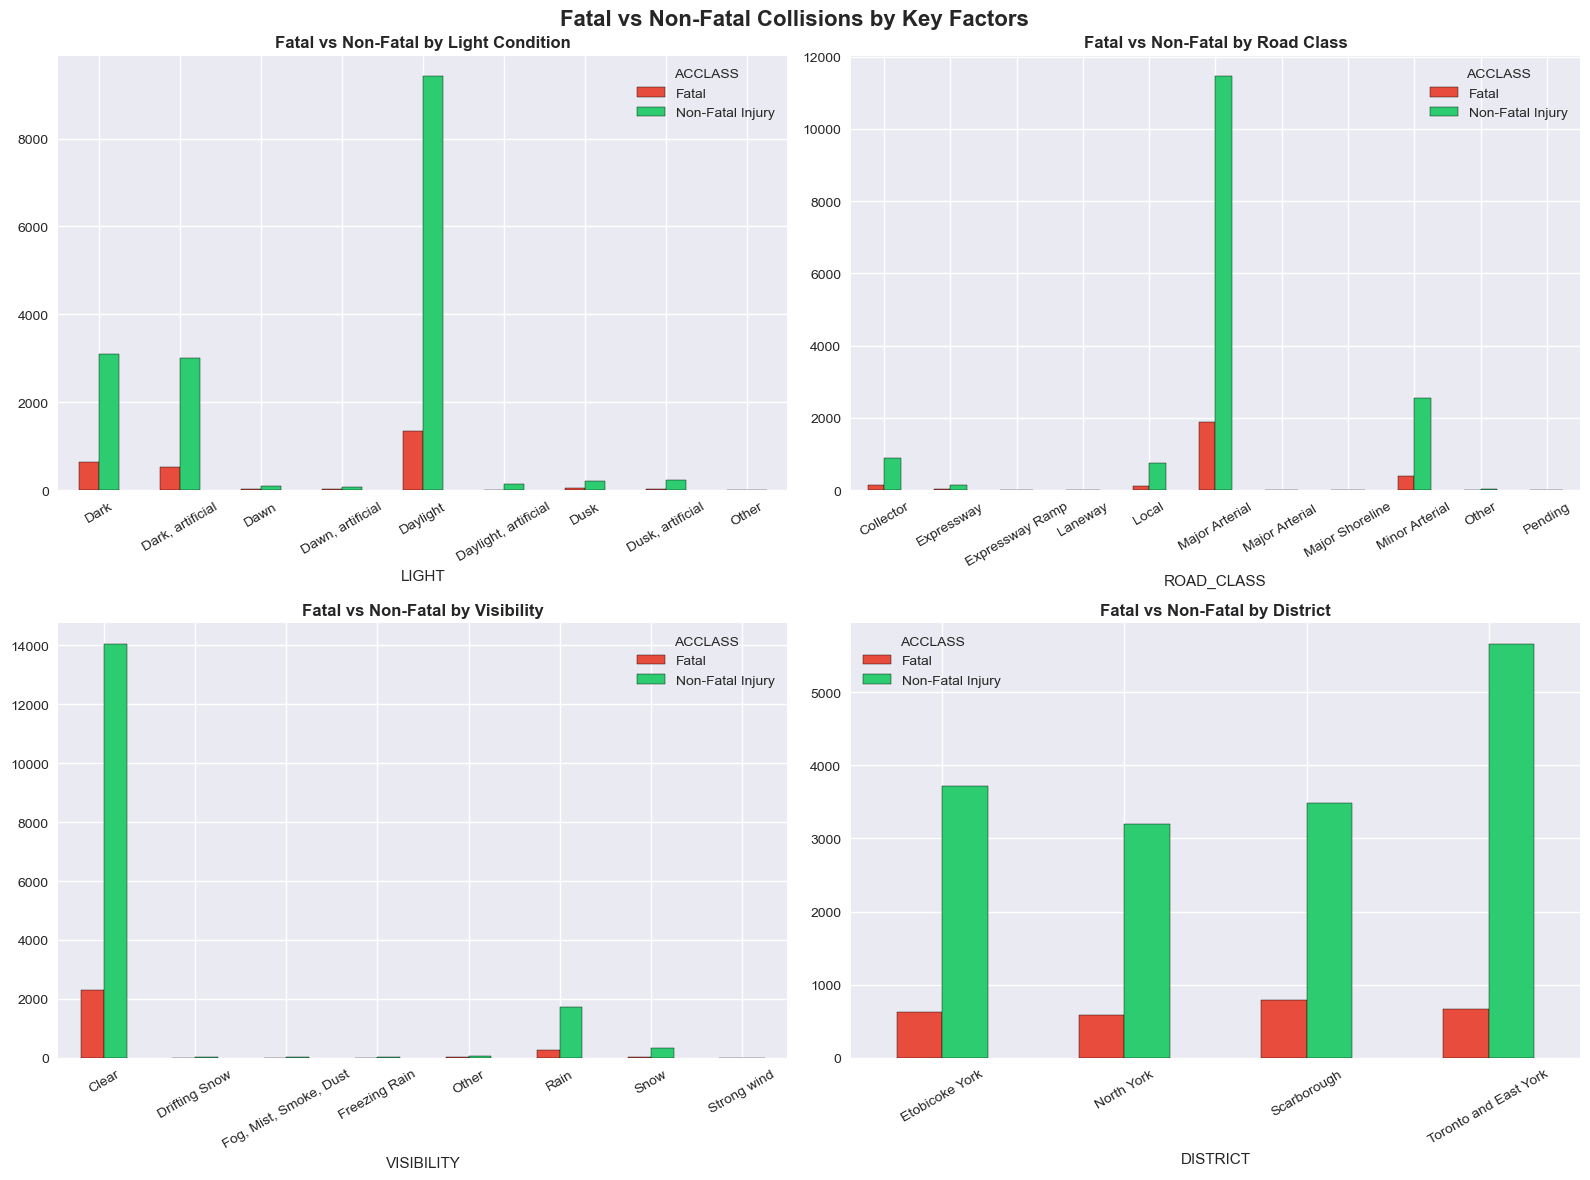

✅ Chart saved as fatal_vs_nonfatal_factors.png


In [12]:
# Filter only Fatal and Non-Fatal (remove Property Damage)
df_filtered = df[df['ACCLASS'].isin(['Fatal', 'Non-Fatal Injury'])].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. By Light condition
light_fatal = df_filtered.groupby(['LIGHT', 'ACCLASS']).size().unstack(fill_value=0)
light_fatal.plot(kind='bar', ax=axes[0,0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0,0].set_title('Fatal vs Non-Fatal by Light Condition', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=30)

# 2. By Road Class
road_fatal = df_filtered.groupby(['ROAD_CLASS', 'ACCLASS']).size().unstack(fill_value=0)
road_fatal.plot(kind='bar', ax=axes[0,1], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0,1].set_title('Fatal vs Non-Fatal by Road Class', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=30)

# 3. By Visibility
vis_fatal = df_filtered.groupby(['VISIBILITY', 'ACCLASS']).size().unstack(fill_value=0)
vis_fatal.plot(kind='bar', ax=axes[1,0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1,0].set_title('Fatal vs Non-Fatal by Visibility', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=30)

# 4. By District
dist_fatal = df_filtered.groupby(['DISTRICT', 'ACCLASS']).size().unstack(fill_value=0)
dist_fatal.plot(kind='bar', ax=axes[1,1], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1,1].set_title('Fatal vs Non-Fatal by District', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=30)

plt.suptitle('Fatal vs Non-Fatal Collisions by Key Factors', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('fatal_vs_nonfatal_factors.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as fatal_vs_nonfatal_factors.png')

## 1.11 — Correlation Analysis
📸 **CAPTURE 9 : Screenshot of correlation heatmap**

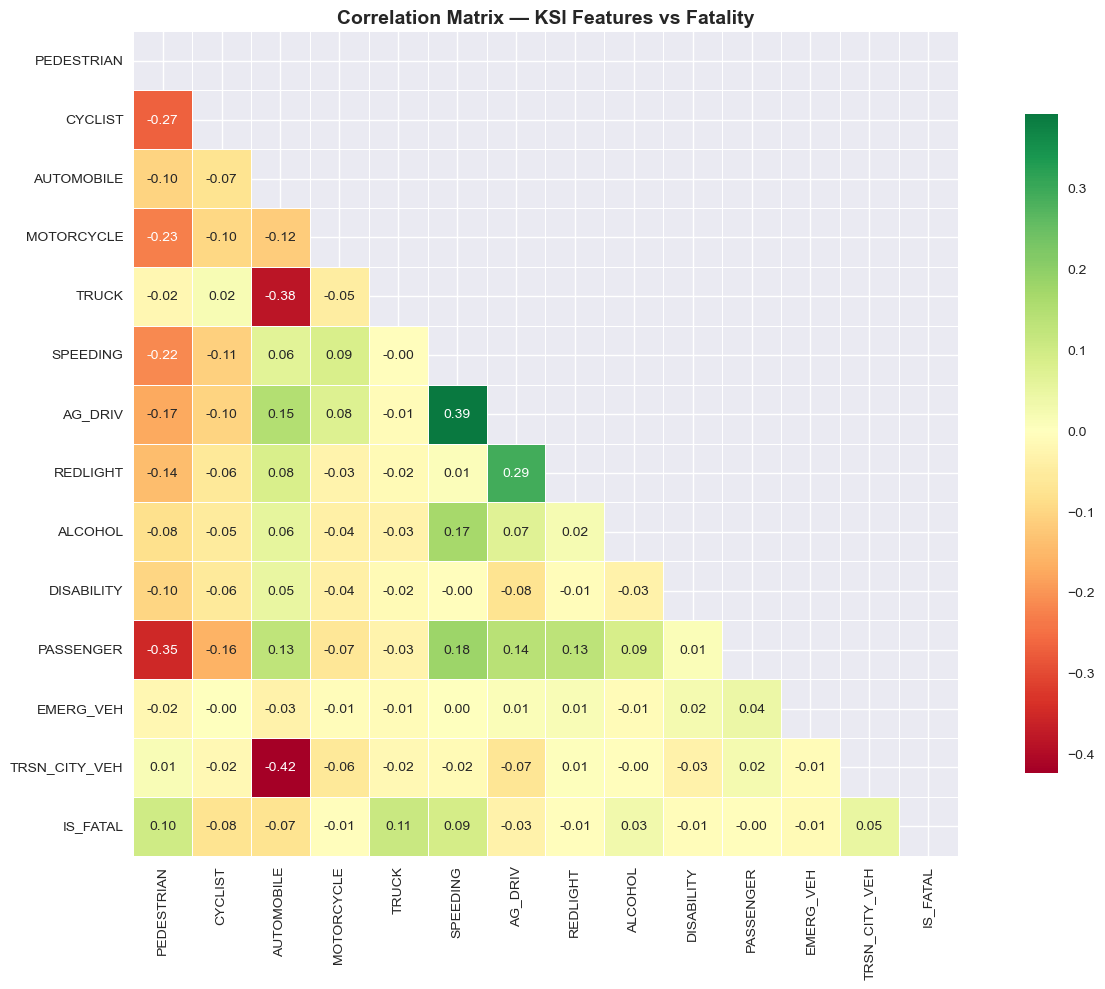

✅ Chart saved as correlation_matrix.png


In [13]:
# Create binary encoded version for correlation
df_corr = df_filtered.copy()

# Encode target
df_corr['IS_FATAL'] = (df_corr['ACCLASS'] == 'Fatal').astype(int)

# Encode binary Yes/No columns
binary_cols = ['PEDESTRIAN', 'CYCLIST', 'AUTOMOBILE', 'MOTORCYCLE', 
               'TRUCK', 'SPEEDING', 'AG_DRIV', 'REDLIGHT', 'ALCOHOL', 
               'DISABILITY', 'PASSENGER', 'EMERG_VEH', 'TRSN_CITY_VEH']

for col in binary_cols:
    if col in df_corr.columns:
        df_corr[col] = (df_corr[col] == 'Yes').astype(int)

# Select numeric columns for correlation
numeric_cols = binary_cols + ['IS_FATAL']
numeric_cols = [c for c in numeric_cols if c in df_corr.columns]

corr_matrix = df_corr[numeric_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn',
            mask=mask,
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — KSI Features vs Fatality', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as correlation_matrix.png')

In [14]:
# Top correlations with IS_FATAL
print('🎯 Top correlations with FATALITY:')
print('='*40)
fatal_corr = corr_matrix['IS_FATAL'].drop('IS_FATAL').sort_values(key=abs, ascending=False)
print(fatal_corr.round(3))

🎯 Top correlations with FATALITY:
TRUCK            0.111
PEDESTRIAN       0.099
SPEEDING         0.090
CYCLIST         -0.075
AUTOMOBILE      -0.075
TRSN_CITY_VEH    0.048
AG_DRIV         -0.033
ALCOHOL          0.029
EMERG_VEH       -0.015
DISABILITY      -0.007
REDLIGHT        -0.006
MOTORCYCLE      -0.006
PASSENGER       -0.004
Name: IS_FATAL, dtype: float64


## 1.12 — Export Clean Data for Power BI
📸 **CAPTURE 10 : Screenshot confirming CSV export**

In [18]:
# Export enriched dataset for Power BI visualization
df_powerbi = df_filtered.copy()
df_powerbi['IS_FATAL'] = (df_powerbi['ACCLASS'] == 'Fatal').astype(int)
df_powerbi['YEAR'] = pd.to_datetime(df_powerbi['DATE']).dt.year
df_powerbi['MONTH'] = pd.to_datetime(df_powerbi['DATE']).dt.month
df_powerbi['MONTH_NAME'] = pd.to_datetime(df_powerbi['DATE']).dt.month_name()
df_powerbi['DAY_OF_WEEK'] = pd.to_datetime(df_powerbi['DATE']).dt.day_name()

export_path = r'C:\Users\HP\Desktop\Artificial Intelligence - Software Engineering Technology (Fast-Track)\26W --Supervised Learning (SEC. 402)\COMP247_KSI_Project\powerbi\KSI_PowerBI.csv'

df_powerbi.to_csv(export_path, index=False)
print('✅ Dataset exported for Power BI')
print(f'   Rows    : {len(df_powerbi):,}')
print(f'   Columns : {df_powerbi.shape[1]}')

✅ Dataset exported for Power BI
   Rows    : 18,938
   Columns : 59


## ✅ Step 1 Summary

| Item | Value |
|------|-------|
| Total Records | 18,957 |
| Fatal Collisions | 2,670 (14.1%) |
| Non-Fatal Collisions | 16,268 (85.8%) |
| Total Columns | 54 |
| Date Range | 2006 – 2023 |
| Target Variable | ACCLASS (Fatal / Non-Fatal) |

**Next Step → Step 2: Power BI Visualization + Data Cleaning**